In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)
n_students = 100
study_hours=np.random.uniform(0,10,n_students)


In [3]:
study_hours

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456,
       9.69584628, 7.75132823, 9.39498942, 8.9482735 , 5.97899979,
       9.21874235, 0.88492502, 1.95982862, 0.45227289, 3.25330331,
       3.8867729 , 2.71349032, 8.28737509, 3.56753327, 2.8093451 ,
       5.42696083, 1.40924225, 8.02196981, 0.74550644, 9.86886937,
       7.72244769, 1.98715682, 0.05522117, 8.15461428, 7.06857

In [4]:
true_slope=7    #defining n
true_intercept=30  # defining intecept
noise=np.random.uniform(0,5,n_students)

marks=true_slope*study_hours+true_intercept+noise




In [5]:
marks

array([ 56.37495425,  99.73205351,  82.81135583,  74.44894735,
        45.4591372 ,  42.16607757,  36.11776747,  94.4100859 ,
        73.22204165,  79.94997999,  32.88967187,  98.69979609,
        92.91947312,  48.90433965,  45.89476649,  47.19561864,
        55.31531739,  67.66580051,  64.6989463 ,  53.08275102,
        76.86690341,  44.24502675,  52.04014277,  56.19558865,
        63.06457471,  87.09785624,  48.06723858,  70.30006361,
        71.50378047,  35.8052654 ,  74.61519465,  43.04722771,
        35.15293835,  98.11006346, 102.30879083,  88.20382903,
        53.91691695,  40.35214277,  79.71445987,  65.66958498,
        43.35491291,  65.92129519,  34.89343901,  95.15681969,
        49.53880118,  76.56099464,  54.867597  ,  68.9181566 ,
        68.52711331,  44.33304421, 102.41225337,  85.45710709,
        96.48940027,  95.08517833,  76.78125079,  95.74147281,
        39.55515288,  47.52689845,  34.35409794,  56.4142049 ,
        59.04632594,  52.15596138,  91.17927419,  57.65

In [6]:
regression_df=pd.DataFrame({
    "study_hours":study_hours,
    "marks":marks
})

In [7]:
regression_df.head()

,study_hours,marks
0,3.745401,56.374954
1,9.507143,99.732054
2,7.319939,82.811356
3,5.986585,74.448947
4,1.560186,45.459137


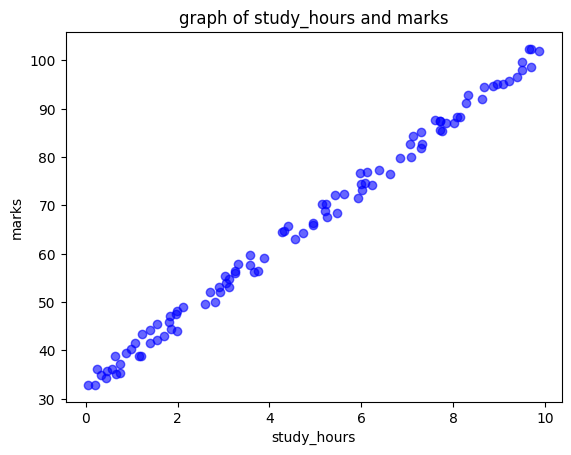

In [8]:
plt.Figure(figsize=(10,6))
plt.scatter(study_hours,marks,color='blue',alpha=0.6)
plt.xlabel("study_hours")
plt.ylabel("marks")
plt.title("graph of study_hours and marks") 
plt.show()

In [9]:
x=regression_df[['study_hours']]
y=regression_df['marks']

In [10]:
x.head()

,study_hours
0,3.745401
1,9.507143
2,7.319939
3,5.986585
4,1.560186


In [11]:
y.head()

0    56.374954
1    99.732054
2    82.811356
3    74.448947
4    45.459137
Name: marks, dtype: float64

In [12]:
print("Before split")
print("study_hours shape:",{x.shape})
print("marks shape",y.shape)


Before split
study_hours shape: {(100, 1)}
marks shape (100,)


split the data into tyraining and testing (80% train and 20%)

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

checking the shape after spliting


In [14]:
print(f"x_train shape:{x_train.shape}")
print(f"x_test shape:{x_test.shape}")
print(f"y_train shape:{y_train.shape}")
print(f"y_test shape:{y_test.shape}")

x_train shape:(80, 1)
x_test shape:(20, 1)
y_train shape:(80,)
y_test shape:(20,)


create and train the linear regressiuon

In [15]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print(model.coef_[0])
print(model.intercept_)

6.97069615740209
32.65972256032863


In [17]:
y_pred= model.predict(x_test)

In [18]:
y_pred

array([37.09018204, 95.03541829, 86.49055902, 78.84213798, 50.69848879,
       63.34141553, 53.02423835, 92.8240399 , 34.09460511, 58.76777623,
       62.76929738, 75.00982821, 89.50306102, 98.80365024, 40.99627407,
       43.53530793, 86.42263498, 37.82115025, 90.68676974, 44.5464411 ])

In [19]:
y_test

83    38.835781
53    95.085178
70    87.444956
45    76.560995
44    49.538801
39    65.669585
22    52.040143
80    92.122572
10    32.889672
0     56.374954
18    64.698946
30    74.615195
73    88.214779
33    98.110063
90    38.837111
4     45.459137
76    87.443613
77    37.116802
12    92.919473
31    43.047228
Name: marks, dtype: float64

In [20]:
compare = pd.DataFrame({"Actual value":y_test,"Predicted value":y_pred})
compare

,Actual value,Predicted value
83,38.835781,37.090182
53,95.085178,95.035418
70,87.444956,86.490559
45,76.560995,78.842138
44,49.538801,50.698489
39,65.669585,63.341416
22,52.040143,53.024238
80,92.122572,92.824040
10,32.889672,34.094605
0,56.374954,58.767776


In [21]:
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [22]:
r2

0.9951294009974142

In [23]:
print(f"model coefficient (model learned): {model.coef_[0]:.2f}")
print(f"model intercept (model learned): {model.intercept_:.2f}")
print(f"mean_squared_error: {mse:.2f}")
print(f"R2 score: {r2:.2f}")

model coefficient (model learned): 6.97
model intercept (model learned): 32.66
mean_squared_error: 2.39
R2 score: 1.00


visualize the regression line

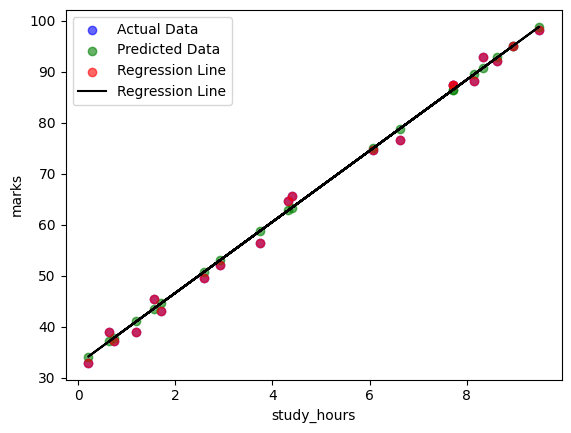

In [24]:
plt.scatter(x_test, y_test, color='blue',alpha=0.6,label='Actual Data')
plt.scatter(x_test, y_pred, color='Green',alpha=0.6,label='Predicted Data')
plt.scatter(x_test, y_test, color='Red',alpha=0.6,label='Regression Line')
plt.plot(x_test,y_pred,color='black', label='Regression Line') 
plt.xlabel("study_hours")
plt.ylabel("marks")
plt.legend()

prediction for new students


In [25]:
x_test

,study_hours
83,0.635584
53,8.948274
70,7.722448
45,6.625223
44,2.587800
39,4.401525
22,2.921446
80,8.631034
10,0.205845
0,3.745401


new study hours

In [26]:
new_study_hours=6.5

predicted_marks=model.predict([[new_study_hours]])
predicted_marks

c:\Users\Piyush Deo\Desktop\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([77.96924758])

In [27]:
print(f"If a student studies for{new_study_hours} hours,then his is predicted marks{predicted_marks[0]:.2f}")

If a student studies for6.5 hours,then his is predicted marks77.97
